# Examen Final - Modelos para pronósticos no lineales

- Stonks
- Aissa Berenice
- Tiburivan
- Colomé

## Definición del problema

## Data Loading

In [1]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguegamefinder, playergamelog

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
# IDs oficiales de la NBA
ID_LAKERS = '1610612747'
ID_LEBRON = '2544'
ID_LUKA = '1629029' # ID oficial de Luka en la NBA

# 1. Obtener TODO el calendario de los Lakers en la temporada 2025-26
game_finder = leaguegamefinder.LeagueGameFinder(team_id_nullable=ID_LAKERS, season_nullable='2025-26')
lakers_games = game_finder.get_data_frames()[0]

# Filtrar solo partidos de temporada regular (eliminar pretemporada si aplica)
lakers_games = lakers_games[lakers_games['MIN'] > 0][['GAME_ID', 'GAME_DATE', 'MATCHUP']].drop_duplicates()
lakers_games = lakers_games[(lakers_games["GAME_DATE"] >= "2025-10-21") & (lakers_games["GAME_DATE"] <= "2026-04-12")]

In [3]:
# 2. Obtener los logs reales de LeBron
time.sleep(0.5) # Pausa para evitar bloqueos de la NBA
lebron_log = playergamelog.PlayerGameLog(player_id=ID_LEBRON, season='2025-26').get_data_frames()[0]
lebron_log = lebron_log[['Game_ID', 'MIN']].rename(columns={'MIN': 'MIN_LeBron', "Game_ID": "GAME_ID"})

In [4]:
# 3. Obtener los logs reales de Luka
time.sleep(0.5)
luka_log = playergamelog.PlayerGameLog(player_id=ID_LUKA, season='2025-26').get_data_frames()[0]
luka_log = luka_log[['Game_ID', 'MIN']].rename(columns={'MIN': 'MIN_Luka', "Game_ID": "GAME_ID"})

In [5]:
# 4. Cruzar el calendario del equipo con los minutos de los jugadores (LEFT JOIN)
df_ts = lakers_games.merge(lebron_log, on='GAME_ID', how='left')
df_ts = df_ts.merge(luka_log, on='GAME_ID', how='left')

df_ts['MIN_LeBron'] = df_ts['MIN_LeBron'].fillna(0)
df_ts['MIN_Luka'] = df_ts['MIN_Luka'].fillna(0)

In [6]:
# 1. Asegurar que la fecha esté en formato datetime y ordenada
df_ts['GAME_DATE'] = pd.to_datetime(df_ts['GAME_DATE'])
df_ts = df_ts.sort_values('GAME_DATE')

# 2. Calcular la diferencia de días entre el partido actual y el anterior
# .diff() resta el valor de la fila anterior. .dt.days lo convierte a número entero.
df_ts['Days_Since_Last_Game'] = df_ts['GAME_DATE'].diff().dt.days

# 3. Crear la variable binaria Back-to-Back (B2B)
# Si la diferencia es exactamente 1 día, es un B2B.
df_ts['Is_B2B'] = (df_ts['Days_Since_Last_Game'] == 1).astype(int)

# 4. (Opcional) Detectar si es el primer o segundo juego del B2B
# A veces el cansancio afecta más en el segundo día.
df_ts['Is_B2B_Second_Night'] = df_ts['Is_B2B'] 

# Visualizar el resultado
print(df_ts[['GAME_DATE', 'MATCHUP', 'Days_Since_Last_Game', 'Is_B2B']].head(10))

    GAME_DATE      MATCHUP  Days_Since_Last_Game  Is_B2B
81 2025-10-21  LAL vs. GSW                   NaN       0
80 2025-10-24  LAL vs. MIN                   3.0       0
79 2025-10-26    LAL @ SAC                   2.0       0
78 2025-10-27  LAL vs. POR                   1.0       1
77 2025-10-29    LAL @ MIN                   2.0       0
76 2025-10-31    LAL @ MEM                   2.0       0
75 2025-11-02  LAL vs. MIA                   2.0       0
74 2025-11-03    LAL @ POR                   1.0       1
73 2025-11-05  LAL vs. SAS                   2.0       0
72 2025-11-08    LAL @ ATL                   3.0       0


In [7]:
# 5. Limpieza de datos y conversión a minutos numéricos
def clean_minutes(val):
    if pd.isna(val) or val == 0:
        return 0.0
    # Convertir formato "MM:SS" de la NBA a decimal
    if ':' in str(val):
        parts = str(val).split(':')
        return float(parts[0]) + float(parts[1]) / 60
    return float(val)

df_ts['MIN_LeBron'] = df_ts['MIN_LeBron'].apply(clean_minutes)
df_ts['MIN_Luka'] = df_ts['MIN_Luka'].apply(clean_minutes)

# 6. Crear la variable exógena: ¿Jugó Luka? (1 = Sí, 0 = No, porque sus minutos fueron 0)
df_ts['Luka_Playing'] = df_ts['MIN_Luka'].apply(lambda x: 1 if x > 0 else 0)

# Ordenar cronológicamente para la serie de tiempo
df_ts = df_ts.sort_values('GAME_DATE').reset_index(drop=True)

print(df_ts[['GAME_DATE', 'MATCHUP', 'MIN_LeBron', 'MIN_Luka', 'Luka_Playing', "Is_B2B"]])

    GAME_DATE      MATCHUP  MIN_LeBron  MIN_Luka  Luka_Playing  Is_B2B
0  2025-10-21  LAL vs. GSW         0.0      41.0             1       0
1  2025-10-24  LAL vs. MIN         0.0      35.0             1       0
2  2025-10-26    LAL @ SAC         0.0       0.0             0       0
3  2025-10-27  LAL vs. POR         0.0       0.0             0       1
4  2025-10-29    LAL @ MIN         0.0       0.0             0       0
..        ...          ...         ...       ...           ...     ...
77 2026-04-05    LAL @ DAL        39.0       0.0             0       0
78 2026-04-07  LAL vs. OKC         0.0       0.0             0       0
79 2026-04-09    LAL @ GSW        32.0       0.0             0       0
80 2026-04-10  LAL vs. PHX        32.0       0.0             0       1
81 2026-04-12  LAL vs. UTA        17.0       0.0             0       0

[82 rows x 6 columns]


In [8]:
df_ts['GAME_DATE'] = pd.to_datetime(df_ts['GAME_DATE'])
df_ts = df_ts.sort_values('GAME_DATE')

# 2. Crear la figura
fig = go.Figure()

# --- Trace 1: Minutos de Luka Dončić (Nueva Variable Exógena Continua) ---
fig.add_trace(go.Scatter(
    x=df_ts['GAME_DATE'],
    y=df_ts['MIN_Luka'],
    mode='lines',
    name='Minutos Luka',
    fill='tozeroy', # Sombreado bajo la curva de Luka
    fillcolor='rgba(0, 102, 204, 0.2)', # Azul Mavericks/Lakers con transparencia
    line=dict(color='rgba(0, 102, 204, 0.5)', width=2),
    hovertemplate='<b>Fecha:</b> %{x}<br><b>Luka:</b> %{y:.1f} min<extra></extra>'
))

# --- Trace 2: Minutos de LeBron James (Variable Objetivo) ---
fig.add_trace(go.Scatter(
    x=df_ts['GAME_DATE'],
    y=df_ts['MIN_LeBron'],
    mode='lines+markers',
    name='Minutos LeBron',
    line=dict(color='#552583', width=3), # Púrpura Lakers
    marker=dict(size=7, color='#FDB927', line=dict(width=1, color='black')), # Oro Lakers
    hovertemplate='<b>Fecha:</b> %{x}<br><b>LeBron:</b> %{y:.1f} min<extra></extra>'
))

# --- Trace 3: Indicador de Back-to-Back (B2B) ---
# Mantenemos las barras rojas para identificar el estrés del calendario
fig.add_trace(go.Bar(
    x=df_ts[df_ts['Is_B2B'] == 1]['GAME_DATE'],
    y=[55] * len(df_ts[df_ts['Is_B2B'] == 1]), 
    name='Back-to-Back',
    marker_color='rgba(255, 0, 0, 0.15)', 
    width=86400000 * 0.7, 
    hoverinfo='skip' # No mostrar hover para el B2B para no ensuciar
))

# 3. Configuración del diseño
fig.update_layout(
    title=dict(
        text='Interacción de Minutos: LeBron James vs Luka Dončić (2025-26)',
        x=0.5, font=dict(size=22)
    ),
    xaxis_title='Calendario de Temporada',
    yaxis_title='Minutos Jugados',
    template='plotly_white',
    hovermode='x unified',
    yaxis=dict(range=[0, 55], gridcolor='lightgrey'),
    xaxis=dict(showgrid=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=50, r=50, t=100, b=50)
)

fig.show()

## Pruebas de Estacionareidad, ACF y PACF

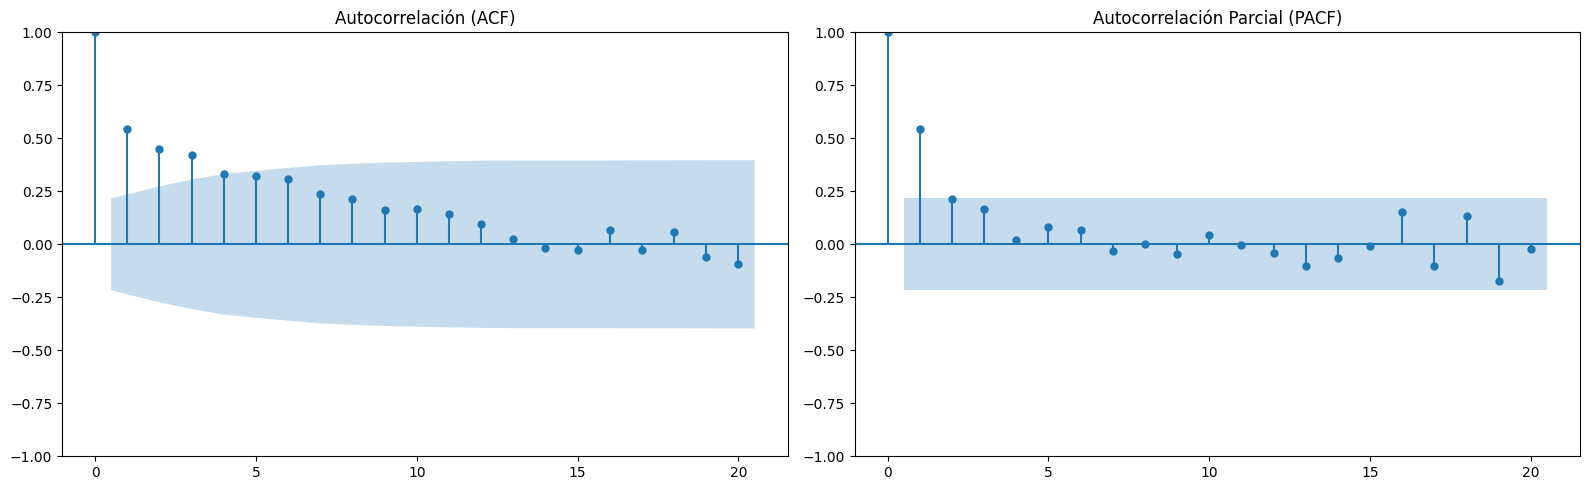

In [9]:
def autocorrelation_plots(timeseries):
    # 2. Configuración de gráficas ACF y PACF
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Gráfica de Autocorrelación (ACF) - Ayuda a identificar el término MA (q)
    plot_acf(timeseries.dropna(), ax=ax1, lags=20, title='Autocorrelación (ACF)')
    
    # Gráfica de Autocorrelación Parcial (PACF) - Ayuda a identificar el término AR (p)
    plot_pacf(timeseries.dropna(), ax=ax2, lags=20, title='Autocorrelación Parcial (PACF)', method='ywm')

    plt.tight_layout()
    plt.show()

# Aplicar a los minutos de LeBron
autocorrelation_plots(df_ts['MIN_LeBron'])

## Escalamiento de datos

In [10]:
df_model = df_ts[['MIN_LeBron', 'Is_B2B', 'Luka_Playing']].dropna().reset_index(drop=True)

# 2. Train/Test Split (80% entrenamiento, 20% prueba)
train_size = int(len(df_model) * 0.8)
train, test = df_model.iloc[:train_size], df_model.iloc[train_size:]

# 3. MinMax Scaler
# Escalamos las variables exógenas y la objetivo por separado para poder invertir el proceso después
scaler_y = MinMaxScaler()
scaler_x = MinMaxScaler()

# Ajustar y transformar entrenamiento
train_y = scaler_y.fit_transform(train[['MIN_LeBron']])
train_x = scaler_x.fit_transform(train[['Is_B2B', 'Luka_Playing']])

# Transformar prueba (usando el ajuste de entrenamiento para evitar data leakage)
test_y = scaler_y.transform(test[['MIN_LeBron']])
test_x = scaler_x.transform(test[['Is_B2B', 'Luka_Playing']])

## Arquitectura del Modelo

## Entrenamiento del Modelo

In [11]:
# 1. Definir la arquitectura de la FFNN
model_ffnn = Sequential([
    Dense(64, activation='relu', input_shape=(train_x.shape[1],)),
    Dropout(0.2), # Para evitar el sobreajuste
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='relu') # Salida lineal para regresión
])

model_ffnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 2. Configurar Early Stopping para no sobre-entrenar
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 3. Entrenar el modelo
history = model_ffnn.fit(
    train_x, train_y,
    epochs=150,
    batch_size=4,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# 4. Predicciones
y_pred_ffnn_scaled = model_ffnn.predict(test_x)
y_pred_ffnn = scaler_y.inverse_transform(y_pred_ffnn_scaled)

c:\Users\Roi_f\sexto_sem\Modelos_no_lineales\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.3192 - mae: 0.5103 - val_loss: 0.1640 - val_mae: 0.3964
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2010 - mae: 0.3955 - val_loss: 0.2181 - val_mae: 0.3564
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1892 - mae: 0.3481 - val_loss: 0.2149 - val_mae: 0.3555
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1906 - mae: 0.3515 - val_loss: 0.1945 - val_mae: 0.3610
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1713 - mae: 0.3561 - val_loss: 0.1798 - val_mae: 0.3668
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1555 - mae: 0.3381 - val_loss: 0.2042 - val_mae: 0.3560
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1767 - mae: 0.3228 - val_loss: 0.2068 - val_mae: 0.3552
Epoch 8/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1630 - mae: 0.3248 - val_loss: 0.1793 - val_mae: 0.3657
Epoch 9/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss

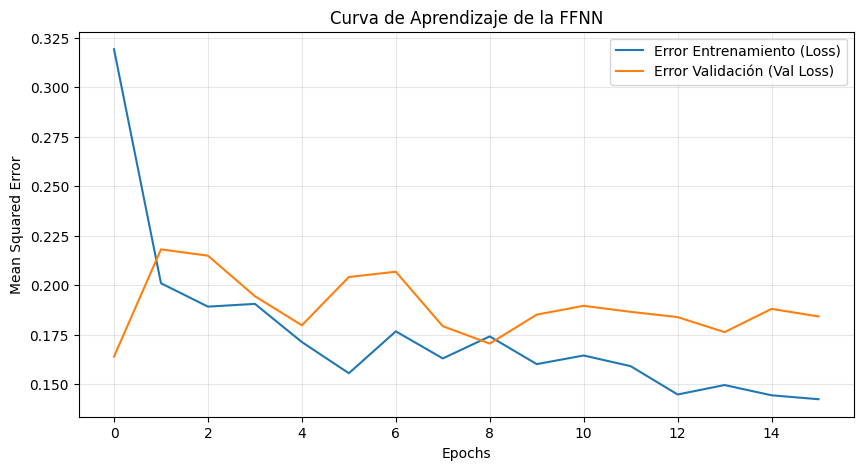

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Error Entrenamiento (Loss)')
plt.plot(history.history['val_loss'], label='Error Validación (Val Loss)')
plt.title('Curva de Aprendizaje de la FFNN')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Pronóstico

In [14]:
import plotly.graph_objects as go

# Preparar los datos para la gráfica
indices_test = range(len(test_y))

fig = go.Figure()

# Minutos Reales
fig.add_trace(go.Scatter(
    x=list(indices_test),
    y=test_y.flatten(),
    mode='lines+markers',
    name='Minutos Reales (Test)',
    line=dict(color='#552583', width=3),
    marker=dict(size=8)
))

# Predicción FFNN
fig.add_trace(go.Scatter(
    x=list(indices_test),
    y=y_pred_ffnn.flatten(),
    mode='lines+markers',
    name='Predicción FFNN',
    line=dict(color='#FDB927', width=3, dash='dash'),
    marker=dict(size=8, symbol='x')
))

fig.update_layout(
    title='Validación FFNN: Predicción de Minutos de LeBron James',
    xaxis_title='Partidos en Set de Prueba',
    yaxis_title='Minutos Jugados',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

## Conclusiones